In [2]:
%pip install torchdiffeq

  Obtaining dependency information for torchdiffeq from https://files.pythonhosted.org/packages/b9/35/537f64f2d0b3cfebaae0f903b4e3a3b239abcc99d0f73cb15b9cee9b8212/torchdiffeq-0.2.5-py3-none-any.whl.metadata
  Using cached torchdiffeq-0.2.5-py3-none-any.whl.metadata (440 bytes)
Using cached torchdiffeq-0.2.5-py3-none-any.whl (32 kB)

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!hostname
!nvidia-smi

htc-n33.crc.pitt.edu
/bin/bash: line 1: nvidia-smi: command not found


In [9]:
%pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/8f/a0/7024215e95d456de5883e6732e708d8187d9753a21d32f8ddb3befc0c445/matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/5f/4b/6157f24ca425b89fe2eb7e7be642375711ab671135be21e6faa100f7448c/contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/79/61/1ca198af22f7dd22c17ab86e9024ed3c06299cfdb08170640e9996d501a0/fonttools-4.61.1-cp311-cp311-manylinux2014_x86

In [3]:
%pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/36/4d/4a67f30778a45d542bbea5db2dbfa1e9e100bf9ba64aefe34215ba9f11f6/scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/ca/6e/8942461cf2636cdae083e3eb72622a7fbbfa5cf559c7d13ab250a5dbdc01/scipy-1.16.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 42.0 MB/s eta 0:00:00:00:0100:01

[notice] A new release of 

In [6]:
import sys
print(sys.executable)

/ihome/kkim/bas448/mytorchenv/bin/python


In [1]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\BAS448\Desktop\Research\NODE\main


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import joblib
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence,pack_padded_sequence,pad_packed_sequence, PackedSequence
from sklearn.preprocessing import StandardScaler
from torchdiffeq import odeint

In [2]:
#load the train sets across all 3 scenario
train_s1= np.load('data/nonlinear/scenario_1/train.npy',allow_pickle=True).item()
train_s2= np.load('data/nonlinear/scenario_2/train.npy',allow_pickle=True).item()
train_s3= np.load('data/nonlinear/scenario_3/train.npy',allow_pickle=True).item()
#load the validation sets across all 3 scenario
val_s1= np.load('data/nonlinear/scenario_1/val.npy',allow_pickle=True).item()
val_s2= np.load('data/nonlinear/scenario_2/val.npy',allow_pickle=True).item()
val_s3= np.load('data/nonlinear/scenario_3/val.npy',allow_pickle=True).item()

In [3]:
#gather all unique track lengths
tnums_tr= sorted(set(list(train_s1.keys())+list(train_s2.keys())+list(train_s3.keys())),key=int) #keep it in the order you want
tnums_val= sorted(set(list(val_s1.keys())+list(val_s2.keys())+list(val_s3.keys())),key=int)

In [4]:
train,val={},{}
#build the global set for training and validation
for key in tnums_tr:
    arr=[]
    # Grab the set from Scenario 1
    if key in train_s1:
        arr.append(train_s1[key])  
    # Grab the set from Scenario 2
    if key in train_s2:
        arr.append(train_s2[key])
    # Grab the set from Scenario 3
    if key in train_s3:
        arr.append(train_s3[key])
        
    # Stack them all along axis 0 (num_trajectories axis)
    # e.g., (1400, 5, 2) + (1400, 5, 2) + (1400, 5, 2) -> (4200, 5, 2)
    train[key] = np.concatenate(arr, axis=0)

for key in tnums_val:
    arrv=[]
    # Grab the set from Scenario 1
    if key in val_s1:
        arrv.append(val_s1[key])   
    # Grab the set from Scenario 2
    if key in val_s2:
       arrv.append(val_s2[key]) 
    # Grab the set from Scenario 3
    if key in val_s3:
        arrv.append(val_s3[key]) 
        
    # Stack them all along axis 0 (num_trajectories axis)
    # e.g., (1400, 5, 2) + (1400, 5, 2) + (1400, 5, 2) -> (4200, 5, 2)
    val[key] = np.concatenate(arrv, axis=0)

In [2]:
def pre_process(data,delta_t,scaler,data_type):
  snippets={}
  #data,time_points= organize_data(data,delta_t)
  data= organize_data(data,delta_t)
  physical_width,physical_height= 15,15

  if data_type=="train":
    train_pts = np.concatenate([points[:,:,[0,1,2,3,4,5]].reshape(-1, 6) for points in data.values()], axis=0) #so, these would be the input to the LSTM which would be z-score normalized
    scaler.fit(train_pts)
    scaler_filename = 'standard_scaler_adaptive.pkl'
    joblib.dump(scaler, scaler_filename)
    print(f"Scaler saved to {scaler_filename}")

  #Now, begin the actual pre-processing
  for length_str, points in data.items():
    tracks= torch.from_numpy(points).float()
    #divide the tracks into two different features - one to the LSTM and the other to the ST-GATE
    lstm_feat= tracks[:,:,[0,1,2,3,4,5]]
    stg_feat= tracks[:,:,[6,7,8]]
    #the LSTM-features would be scaled by z-score
    tracksn= scaler.transform(lstm_feat.reshape(-1,lstm_feat.shape[-1]))
    lstm_feat_scaled= torch.tensor(tracksn.reshape(lstm_feat.shape),dtype=torch.float32)
    #the ST-GATE features would be scaled with a reference
    stg_feat[:,:,0]/= 0.02 #divide dt by a reference time
    stg_feat[:,:,1]/= physical_width #divide dx by a reference width
    stg_feat[:,:,2]/= physical_height #divide dz by a reference height

    st_ode_feat= torch.cat((lstm_feat_scaled,stg_feat),axis=2) #concatenate the normalized features

    snippets[length_str]= st_ode_feat

  return snippets

def organize_data(data,delta_t):
  '''input - tracks - [num_trajectories,num_time_points,2]
  output- [x,z,vx,vz,ax,az,dt,dx,dz]
  Of these, [x,z,vx,vz,ax,az]= pi - the feature vector input to the LSTM
  [dt,dx,dz] - the input to the ST-gate - so we might need to perform normalization by group'''
  #max_seq_length= max([int(track_length) for track_length in data.keys()]) #this extracts the dictionary keys from the data that we have spanning different time points
  data_feat={}
  #t= np.linspace(0,delta_t*(max_seq_length-1),max_seq_length)

  for num_t_points,traj_points in data.items():
    x= traj_points[:,:,0]
    z= traj_points[:,:,1]

    dx= np.zeros_like(x) #zeros_like returns an np array with the same shape and size as the original array, but with zeros
    dz= np.zeros_like(z)

    dx[:,1:]= x[:,1:]-x[:,:-1] #performs subtraction on data(2,:)-data(1,:), data(3,:)-data(2,:), ... data(end,:)-data(end-1,:)
    dz[:,1:]= z[:,1:]-z[:,:-1]

    vx= dx/delta_t
    vz= dz/delta_t

    ax= np.zeros_like(x)
    az= np.zeros_like(z)

    #starts from the second index as acceleration requires velocity at two time points to begin
    ax[:,2:]= (vx[:,2:]-vx[:,1:-1])/delta_t
    az[:,2:]= (vz[:,2:]-vz[:,1:-1])/delta_t

    dt= np.full_like(x,delta_t)  #full_like(size of which array to copy, value to fill)

    #convert the 2D array into 3D using expand_dims along the third dimension which will give you a num_traj_points x time_points x 1 array for concatenation
    '''x= np.expand_dims(x,axis=2)
    z= np.expand_dims(z,axis=2)
    vx= np.expand_dims(vx,axis=2)
    vz= np.expand_dims(vz,axis=2)
    ax= np.expand_dims(ax,axis=2)
    az= np.expand_dims(az,axis=2)
    dt= np.expand_dims(dt,axis=2)
    dx= np.expand_dims(dx,axis=2)
    dz= np.expand_dims(dz,axis=2)'''

    feat= np.concatenate((x[:,:,None],z[:,:,None],vx[:,:,None],vz[:,:,None],ax[:,:,None],az[:,:,None],dt[:,:,None],dx[:,:,None],dz[:,:,None]),axis=2)

    data_feat[num_t_points]= feat

  return data_feat

In [3]:
class NODEDataset(Dataset):
  def __init__(self,trajectory_dict):
    self.trajectories= []

    #flatten dictionary for the purpose of loading
    for length_str in trajectory_dict:
      feat= trajectory_dict[length_str] #(number of points, number of time points, number of features)
      for num_traj in range(feat.shape[0]):
        self.trajectories.append(torch.tensor(feat[num_traj],dtype=torch.float32))

  def __len__(self):
    return len(self.trajectories)

  def __getitem__(self,idx):
    return self.trajectories[idx] #access any item from the list of trajectories you have

In [4]:
def custom_collate_func(batch):
  delta_t=0.02
  lengths= torch.tensor([seq.shape[0] for seq in batch]) #this retrieves the number of time points - as we have already flattened it

  #pad the features with zeros
  feat_padded= pad_sequence(batch,batch_first=True,padding_value=0)

  B,T,_= feat_padded.shape

  t= torch.arange(T)*delta_t
  t= t.unsqueeze(0).expand(B,-1)
  # The 't' tensor needs to be expanded to have the same number of dimensions as feat_padded[:,:,:6] and feat_padded[:,:,6:]
  # before being concatenated. Also, ensure the tensors are passed as a tuple to torch.cat.
  # Assuming 't' needs to be inserted as a feature, it needs a dimension for features.
  t = t.unsqueeze(-1)
  feat= torch.cat((feat_padded[:,:,:6], t, feat_padded[:,:,6:]), dim=2)
  return feat,lengths

In [8]:
def plot_reconstruction(gt, pred, lengths, n=4):
    plt.figure(figsize=(4*n, 4))

    for i in range(n):
        T = lengths[i]
        gt_traj = gt[i, :T, :2].cpu().numpy()
        pred_traj = pred[i, :T, :2].cpu().numpy()

        plt.subplot(1, n, i+1)
        plt.plot(gt_traj[:,0], gt_traj[:,1], 'o-', label="GT")
        plt.plot(pred_traj[:,0], pred_traj[:,1], 'x--', label="Recon")
        plt.axis("equal")
        plt.title(f"Traj {i}")
        plt.xlabel('x (mm)')
        plt.ylabel('z (mm)')
        if i == 0:
            plt.legend()

    plt.tight_layout()
    plt.show()

In [9]:
delta_t=0.02
scaler= StandardScaler()

train_snippets= pre_process(train,delta_t,scaler,'train')
val_snippets= pre_process(val,delta_t,scaler,'valid')

Scaler saved to standard_scaler_adaptive.pkl


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
#Access the dataset
data_train= NODEDataset(train_snippets)
data_val= NODEDataset(val_snippets)

C:\Users\BAS448\AppData\Local\Temp\ipykernel_15696\2116832673.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.trajectories.append(torch.tensor(feat[num_traj],dtype=torch.float32))


In [13]:
train_loader= DataLoader(dataset=data_train, batch_size=512, shuffle=True,collate_fn=custom_collate_func)
val_loader= DataLoader(dataset=data_val, batch_size=512, shuffle=True,collate_fn=custom_collate_func)

In [5]:
import torch
import torch.nn as nn

#ST-GATE
class STGate(nn.Module):
  def __init__(self,hidden_dim):
    super(STGate,self).__init__()
    self.mlp= nn.Sequential(
        nn.Linear(3,32),
        nn.ReLU(),
        nn.Linear(32,hidden_dim)
    )

  def forward(self,st_input):
    #st_input= [dx,dy,dz] dim:Bx3
    u= torch.torch.exp(-torch.relu(self.mlp(st_input)))

    return u

#Encoder
class STencoder(nn.Module):
  def __init__(self,input_dim=10,hidden_dim=128):
    super().__init__()
    self.hidden_dim= hidden_dim

    self.lstm_cell= nn.LSTMCell(6,hidden_dim)
    self.st_gate= STGate(hidden_dim)

  def forward(self,packed_seq,return_seq=False):
    data, batch_sizes,sorted_idx,unsorted_idx= packed_seq

    B= batch_sizes[0]

    h = torch.zeros(B, self.hidden_dim, device=data.device)
    c = torch.zeros(B, self.hidden_dim, device=data.device)

    outputs = []
    ptr = 0

    for t, bs in enumerate(batch_sizes):
      # ---- slice packed data ----
      step_data = data[ptr:ptr + bs]
      ptr += bs

      lstm_in = step_data[:, :6]
      stg_in  = step_data[:, 7:10]

      h_active = h[:bs]
      c_active = c[:bs]

      # ---- LSTM update ----
      h_lstm, c_new = self.lstm_cell(lstm_in, (h_active, c_active))

      # ---- ST-Gate ----
      u = self.st_gate(stg_in)

      # ---- gated update ----
      h_new = u * h_active + (1 - u) * h_lstm

      # ---- write back ----
      h = h.clone()
      c = c.clone()
      h[:bs] = h_new
      c[:bs] = c_new

      if return_seq:
        outputs.append(h_new)

    #so the reason why we are packing again is that we aren't using ODE(enc)->z->ODE(dec) which would be a sequence to vector model where the model learns to reconstruct a trajectory at each point from a latent sequence that is given. since we still haven't gone to an ODE yet, we'd be using a sequence-to-sequence model where the decoder tries to reconstruct a sequence given a sequence - for the ST-Gate only case - return_seq Flag is set to True
    if return_seq:
      packed_out = PackedSequence(
            torch.cat(outputs, dim=0),
            batch_sizes,
            sorted_idx,
            unsorted_idx
        )
      return packed_out
    else:
      return h[unsorted_idx]

#add the latent ODE
class LatentODE(nn.Module):
  def __init__(self,hidden_dim):
    super().__init__()
    self.ode_func= nn.Sequential(
        nn.Linear(hidden_dim,hidden_dim),
        nn.Tanh(),
        nn.Linear(hidden_dim,hidden_dim)
    )
  # This forward method now defines the derivative function f(t,y) for odeint.
  # 't' is the current time point (scalar from odeint), 'y' is the current latent state (tensor).
  # The ODE is autonomous (does not explicitly depend on 't'), so 't' is not used here for calculation.
  def forward(self,t,y):
    return self.ode_func(y) # Returns dy/dt

#Decoder
class Decoder(nn.Module):
    def __init__(self, hidden_dim, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, h):
        """
        h: Tensor of shape [T, B, hidden_dim] or [B, hidden_dim]
        """
        return self.net(h)
    
class latentModule(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=128, out_dim=2):
        super().__init__()

        self.encoder = STencoder(
            input_dim=input_dim,
            hidden_dim=hidden_dim
        )

        self.latent= LatentODE(hidden_dim)

        self.decoder = Decoder(
            hidden_dim=hidden_dim,
            out_dim=out_dim
        )

    def forward(self, input, packed_input):
        """
        packed_input: PackedSequence of shape (..., input_dim)
        """
        # Encode sequence -> latent initial state
        h0 = self.encoder(packed_input) 

        #Integrate latent ODE
        # Extract 1D time points up to T_max from the first trajectory in the batch.
        # All trajectories in a batch share the same time points (input_features[0, :, 6]).
        # Use .squeeze() to ensure it's a 1D tensor of shape (T_max,).
        time_points = input[0, :, 6].squeeze()
        #print(f"DEBUG: Shape of time_points before odeint: {time_points.shape}") # Diagnostic print

        # Integrate latent ODE
        # h_traj will have shape (num_time_points, B, hidden_dim)
        h_traj = odeint(self.latent, h0, time_points)

        # Decode the latent trajectory
        # output_decoded will have shape (num_time_points, B, out_dim)
        output_decoded = self.decoder(h_traj)

        return output_decoded

In [6]:
def evaluate(model, scaler, val_loader):
    model.eval()
    total_loss, total_us_loss = 0.0,0.0

    dummy_feat, _ = next(iter(val_loader))
    mu= torch.tensor(scaler.mean_[:2], device=device, dtype=dummy_feat.dtype)
    sd=  torch.tensor(scaler.scale_[:2], device=device, dtype=dummy_feat.dtype)
    
    with torch.no_grad():
        for feat, lengths in val_loader:
            feat = feat.to(device)
            lengths = lengths.cpu()

            packed_input = pack_padded_sequence(
                feat, lengths,
                batch_first=True,
                enforce_sorted=False
            )

            output_decoded = model(feat, packed_input)
            output_decoded = output_decoded.transpose(0, 1)

            packed_pred = pack_padded_sequence(
                output_decoded, lengths,
                batch_first=True,
                enforce_sorted=False
            )

            #track the raw loss in mm
            pred_raw = (packed_pred.data*sd+mu)*1000
            true_raw = (packed_input.data[:, :2]*sd+mu)*1000
            
            loss = torch.mean((pred_raw - true_raw) ** 2)
            
            loss_us = torch.mean(
                (packed_pred.data - packed_input.data[:, :2]) ** 2
            )

            #track the raw loss in microns
            total_loss += (loss.item())
            total_us_loss += (loss_us.item())
    #return RMSE for raw, MSE for scheduler
    return (total_loss / len(val_loader))**0.5, (total_us_loss/len(val_loader))

In [16]:
class EarlyStopping(object):
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf #np.Inf was removed
        self.delta = delta
        self.trace_func = trace_func
    def __call__(self, val_loss):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [17]:
model = latentModule().cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
    )

In [15]:
print(model)

latentModule(
  (encoder): STencoder(
    (lstm_cell): LSTMCell(6, 128)
    (st_gate): STGate(
      (mlp): Sequential(
        (0): Linear(in_features=3, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=128, bias=True)
      )
    )
  )
  (latent): LatentODE(
    (ode_func): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=2, bias=True)
    )
  )
)


In [18]:
#adapt the model for fine tuning
model = latentModule().cuda()

model.load_state_dict(torch.load('TrajODE/model_seq2vec_1.pth'))

##freeze the encoder - to tune the ODE flow and not change the LSTM and ST-Gate
#for param in model.encoder.parameters():
#    param.requires_grad = False
#optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,model.parameters()), lr=5e-4) #only update for the ODE and Decoder

#don't freeze the encoder completely, as scenario 2 and scenario 3 have point scatterers moving much faster with higher tortuosity and acceleration than scenario 1 (simpler)
#instead, let's adapt the encoder to remember the simpler scenario and slowly nudge to learn the complex scenario too so that it can handle the different clinical cases it might observe in general
optimizer = torch.optim.Adam([
    {'params': model.encoder.parameters(), 'lr': 1e-4},   # 10x slower
    {'params': model.latent.parameters(), 'lr': 5e-4},   # 2x slower
    {'params': model.decoder.parameters(),'lr': 5e-4},    # 2x slower
])

#optimizer= torch.optim.Adam(model.parameters(),lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
    )

In [18]:
early_stopping = EarlyStopping(patience=10, verbose=True) #the patience was 7 for the simple scenario, bump it up slightly to give it time 
#because NODEs need time to find the appropriate baseline to settle at the required minima, now that you have a combination of scenarios

dummy_feat, _ = next(iter(train_loader))
mu= torch.tensor(scaler.mean_[:2], device=device, dtype=dummy_feat.dtype)
sd=  torch.tensor(scaler.scale_[:2], device=device, dtype=dummy_feat.dtype)
best_val = float('inf')
for epoch in range(1000):
    model.train()
    total_loss = 0.0

    for feat, lengths in train_loader:
        feat = feat.to(device)
        lengths = lengths.cpu() # Keep lengths on CPU for pack_padded_sequence

        packed_input = pack_padded_sequence(
            feat,                  # includes ST features
            lengths,               # Use lengths here for packing
            batch_first=True,
            enforce_sorted=False
        )

        # Call latentModule.forward, passing the full features, lengths, and packed input
        output_decoded = model(feat, packed_input)

        # output_decoded has shape (T_max, B, out_dim) from ODE integration.
        # Transpose it to (B, T_max, out_dim) to match batch_first for packing
        output_decoded_batch_first = output_decoded.transpose(0, 1)

        # Create a PackedSequence from the decoded output for loss calculation.
        # This ensures we only compare non-padded elements.
        packed_pred = pack_padded_sequence(
            output_decoded_batch_first,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        # ---- reconstruction loss on packed data ----
        # Compare the predicted (packed_pred.data) positions (x, z, which are the first 2 features)
        # with the ground truth positions (packed_input.data[:, :2])
        loss = torch.mean(
            (packed_pred.data - packed_input.data[:, :2]) ** 2
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #track the raw loss
        #in mm
        with torch.no_grad():
            pred_raw = (packed_pred.data*sd+mu)*1000
            true_raw = (packed_input.data[:, :2]*sd+mu)*1000
                
            loss_raw = torch.mean((pred_raw - true_raw) ** 2)
                
            #loss = torch.mean(
            #    (packed_pred.data - packed_input.data[:, :2]) ** 2
            #)
    
            #track the raw loss in microns
            total_loss += (loss_raw.item())

            #total_loss += loss.item()

    train_loss = (total_loss / len(train_loader))**0.5 #do RMSE for raw loss, MSE for the loss to optimizer
    val_loss, val_loss_us = evaluate(model, scaler, val_loader)
    #current_lr = optimizer.param_groups[0]['lr']
    lrs = [pg['lr'] for pg in optimizer.param_groups]
    print(f"Epoch {epoch}: train={train_loss:.6f}, val={val_loss:.6f} | "
      f"lr={lrs[0]:.2e}") #0 is the encoder lr, 1 is the latent lr, 2 is the decoder lr

    # Save best checkpoint every time validation loss improves to a new minimum
    if val_loss_us < best_val:
        best_val = val_loss_us
        torch.save(model.state_dict(), 'model_seq2vec_best.pth')
        print(f"New Best Loss: {val_loss:.4f}µm (Normalized: {val_loss_us:.6f}), saved!")
    scheduler.step(val_loss_us)
    early_stopping(val_loss_us)

    if early_stopping.early_stop:
        print("Early stopping")
        print(f"Early stopping — best validation loss was {best_val:.4f}µm")
        break
    
torch.save(model.state_dict(),'model_seq2vec.pth')

Epoch 0: train=1430.004171, val=533.222614 | lr=1.00e-03
New Best Loss: 533.2226µm (Normalized: 0.013835), saved!
Epoch 1: train=470.862090, val=440.228677 | lr=1.00e-03
New Best Loss: 440.2287µm (Normalized: 0.009431), saved!
Epoch 2: train=423.196653, val=428.969257 | lr=1.00e-03
New Best Loss: 428.9693µm (Normalized: 0.008948), saved!
Epoch 3: train=377.418472, val=368.512763 | lr=1.00e-03
New Best Loss: 368.5128µm (Normalized: 0.006606), saved!
Epoch 4: train=349.540460, val=338.539688 | lr=1.00e-03
New Best Loss: 338.5397µm (Normalized: 0.005580), saved!
Epoch 5: train=332.041273, val=322.928983 | lr=1.00e-03
New Best Loss: 322.9290µm (Normalized: 0.005076), saved!
Epoch 6: train=316.318507, val=309.151614 | lr=1.00e-03
New Best Loss: 309.1516µm (Normalized: 0.004655), saved!
Epoch 7: train=298.139000, val=291.762585 | lr=1.00e-03
New Best Loss: 291.7626µm (Normalized: 0.004141), saved!
Epoch 8: train=272.309569, val=262.407914 | lr=1.00e-03
New Best Loss: 262.4079µm (Normalized: 

KeyboardInterrupt: 

Plot the evaluation of the model

C:\Users\BAS448\AppData\Local\Temp\ipykernel_30540\2116832673.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.trajectories.append(torch.tensor(feat[num_traj],dtype=torch.float32))


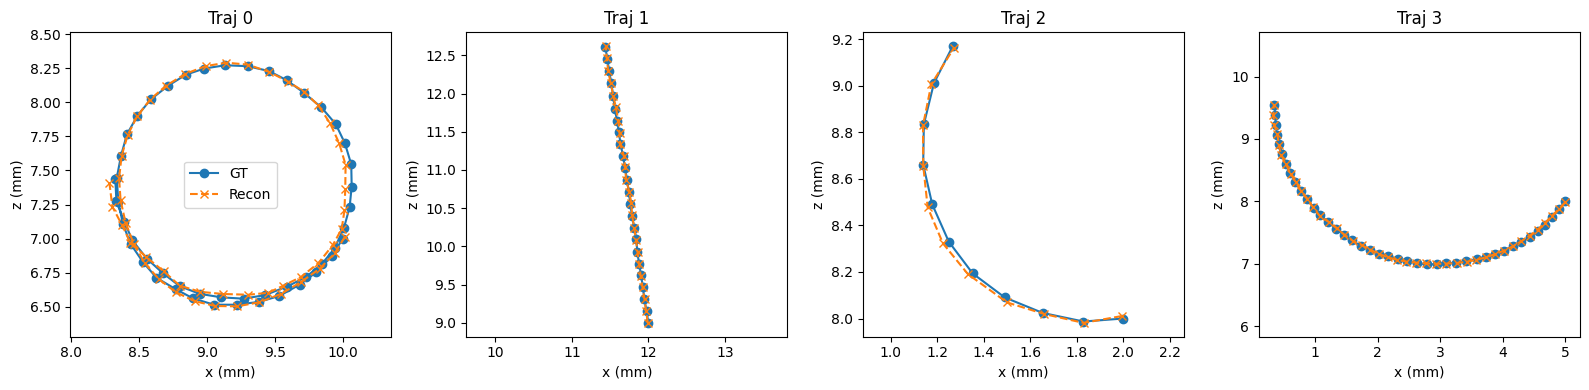

In [52]:
model= latentModule()
test= np.load('data/nonlinear/scenario_1/test.npy',allow_pickle=True).item()
scaler= joblib.load('standard_scaler_adaptive_global.pkl')
test_snippets= pre_process(test,delta_t,scaler,'test')
data_test= NODEDataset(test_snippets)
test_loader= DataLoader(dataset=data_test, batch_size=512, shuffle=True,collate_fn=custom_collate_func)
device = "cpu"
#model.load_state_dict(torch.load('TrajODE/model_seq2vec_3.pth'))
model.load_state_dict(torch.load('model_seq2vec_best.pth', map_location=torch.device('cpu')))
model.eval()

with torch.no_grad():
    feat, lengths = next(iter(test_loader))
    feat= feat.to(device)
    lengths= lengths.cpu()
    packed_input= pack_padded_sequence(feat,lengths,batch_first=True,enforce_sorted=False)
    pred = model(feat, packed_input)
    pred_decoded= pred.transpose(0,1)
    
    mu= torch.tensor(scaler.mean_[:2], device=feat.device, dtype=feat.dtype)
    sd=  torch.tensor(scaler.scale_[:2], device=feat.device, dtype=feat.dtype)

    feat[:,:,:2]= feat[:,:,:2]*sd+mu
    pred_decoded= pred_decoded*sd+mu

    plot_reconstruction(
          feat[:, :, :2],
          pred_decoded,
          lengths
      )

Plot model evaluatio results with insets

In [313]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np
 
 
def get_bbox(gt_xy, pred_xy, pad_frac=0.06):
    """Square bounding box (with padding) around a GT+Recon trajectory pair.
 
    Returns a box with EQUAL width and height (centered on the data), so
    that downstream axes using set_aspect('equal') don't end up with
    lopsided whitespace on just one side -- both axes scale 1:1, like
    grid paper where one unit of x equals one unit of z on the page.
 
    pad_frac is kept tight (0.06, down from 0.15) so the square stays
    "scale constrained": just a thin margin around the trajectory,
    not a loose box with a lot of dead space -- this matters most for
    near-straight/diagonal trajectories, where the natural bounding box
    is thin and squaring it up can otherwise look like wasted padding.
    """
    all_x = np.concatenate([gt_xy[:, 0], pred_xy[:, 0]])
    all_y = np.concatenate([gt_xy[:, 1], pred_xy[:, 1]])
 
    xmin, xmax = all_x.min(), all_x.max()
    ymin, ymax = all_y.min(), all_y.max()
 
    cx, cy = (xmin + xmax) / 2.0, (ymin + ymax) / 2.0
    w, h = xmax - xmin, ymax - ymin
 
    # Use the larger extent for BOTH axes -> guarantees 1mm-x : 1mm-z scale
    half_side = max(w, h) / 2.0
    pad = half_side * 2 * pad_frac + 1e-3  # pad relative to the square side
    half_side += pad
 
    return (cx - half_side, cx + half_side,
            cy - half_side, cy + half_side)
 
 
def plot_reconstruction_with_grid_insets(gt, pred, lengths, n,
                                          inset_indices=None,
                                          title="Scenario - 1",
                                          grid_shape=(2, 2),
                                          savepath=None):
    """
    gt, pred : numpy arrays, shape (n, max_T, >=2)  -- only [:, :, :2] used
    lengths  : numpy array / list, shape (n,)
    n        : number of trajectories in gt/pred (background pool size)
    inset_indices : list of 4 indices to highlight + show as insets
    grid_shape : (rows, cols) for the inset grid -- (2,2) matches the
                 reference; use (1,4) for a single row instead.
    """
    plt.rcParams.update({'font.size': 12})
    if inset_indices is None:
        inset_indices = [0, 1, 2, 3]
    labels = ["A", "B", "C", "D"]
    label_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd']
 
    GT_COLOR = 'red'
    RECON_COLOR = 'blue'
 
    rows, cols = grid_shape
    # Figure height scales with how many inset rows we need, so panels
    # stay generously sized regardless of grid_shape.
    fig_h = 8 + rows * 3.4
    fig = plt.figure(figsize=(10, fig_h))
    main_h_frac = 8 / fig_h
    gs = gridspec.GridSpec(1 + rows, cols, height_ratios=[8] + [3.2] * rows,
                           hspace=0.22, wspace=0.18)
 
    ax_main = fig.add_subplot(gs[0, :])
 
    # --- Background context trajectories (unchanged) ---
    for i in range(n):
        if i in inset_indices:
            continue
        T = lengths[i]
        gt_traj = gt[i, :T, :2]
        pred_traj = pred[i, :T, :2]
        ax_main.plot(gt_traj[:, 0], gt_traj[:, 1], '-', color=GT_COLOR, alpha=0.4, linewidth=0.6)
        ax_main.plot(pred_traj[:, 0], pred_traj[:, 1], '--', color=RECON_COLOR, alpha=0.4, linewidth=0.6)
 
    bboxes = [get_bbox(gt[idx, :lengths[idx], :2], pred[idx, :lengths[idx], :2])
              for idx in inset_indices]
 
    # --- Highlighted trajectories + boxes/labels on main plot ---
    for j, idx in enumerate(inset_indices):
        T = lengths[idx]
        gt_xy = gt[idx, :T, :2]
        pred_xy = pred[idx, :T, :2]
        ax_main.plot(gt_xy[:, 0], gt_xy[:, 1], 'o-', color=GT_COLOR, markersize=3,
                     linewidth=1.6, zorder=5)
        ax_main.plot(pred_xy[:, 0], pred_xy[:, 1], 'x--', color=RECON_COLOR, markersize=3,
                     linewidth=1.4, zorder=5)
        xmin, xmax, ymin, ymax = bboxes[j]
        rect = patches.FancyBboxPatch(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            boxstyle="square,pad=0", linewidth=1.2, edgecolor='black', facecolor='none', zorder=6
        )
        ax_main.add_patch(rect)
        ax_main.text(xmax, ymax, labels[j], color=label_colors[j],
                     fontsize=12, fontweight='bold', va='bottom')
 
    ax_main.grid(True, linestyle=':', alpha=0.6) # Added grid for better readability
    ax_main.set_title(title)
    ax_main.set_xlabel('x (mm)')
    ax_main.set_ylabel('z (mm)')
    # 1 unit of x == 1 unit of z on the page, like grid-paper scaling
    ax_main.set_aspect('equal', adjustable='box')
    ax_main.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
    ax_main.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color=GT_COLOR, linestyle='-', label='GT'),
        plt.Line2D([0], [0], marker='x', color=RECON_COLOR, linestyle='--', label='Recon'),
    ]
    ax_main.legend(handles=legend_handles, loc='upper right')
 
    # --- Simple uniform grid insets: axes off, plain corner label ---
    for j, idx in enumerate(inset_indices):
        r = 1 + j // cols
        c = j % cols
        ax = fig.add_subplot(gs[r, c])
 
        T = lengths[idx]
        gt_xy = gt[idx, :T, :2]
        pred_xy = pred[idx, :T, :2]
        ax.plot(gt_xy[:, 0], gt_xy[:, 1], 'o-', color=GT_COLOR, markersize=4, linewidth=1.4)
        ax.plot(pred_xy[:, 0], pred_xy[:, 1], 'x--', color=RECON_COLOR, markersize=4, linewidth=1.2)
 
        xmin, xmax, ymin, ymax = bboxes[j]
        ax.grid(True, linestyle=':', alpha=0.6) # Added grid for better readability
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        # Same 1:1 grid-paper scaling on every inset panel
        ax.set_aspect('equal', adjustable='box')
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.set_xlabel('x (mm)')
        ax.set_ylabel('z (mm)')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1.0)
 
        # Plain text label, bottom-left corner -- matches reference exactly
        ax.text(0.03, 0.06, labels[j], transform=ax.transAxes,
                color=label_colors[j], fontsize=13, fontweight='bold',
                va='bottom', ha='left')
 
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


C:\Users\BAS448\AppData\Local\Temp\ipykernel_4720\2116832673.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.trajectories.append(torch.tensor(feat[num_traj],dtype=torch.float32))


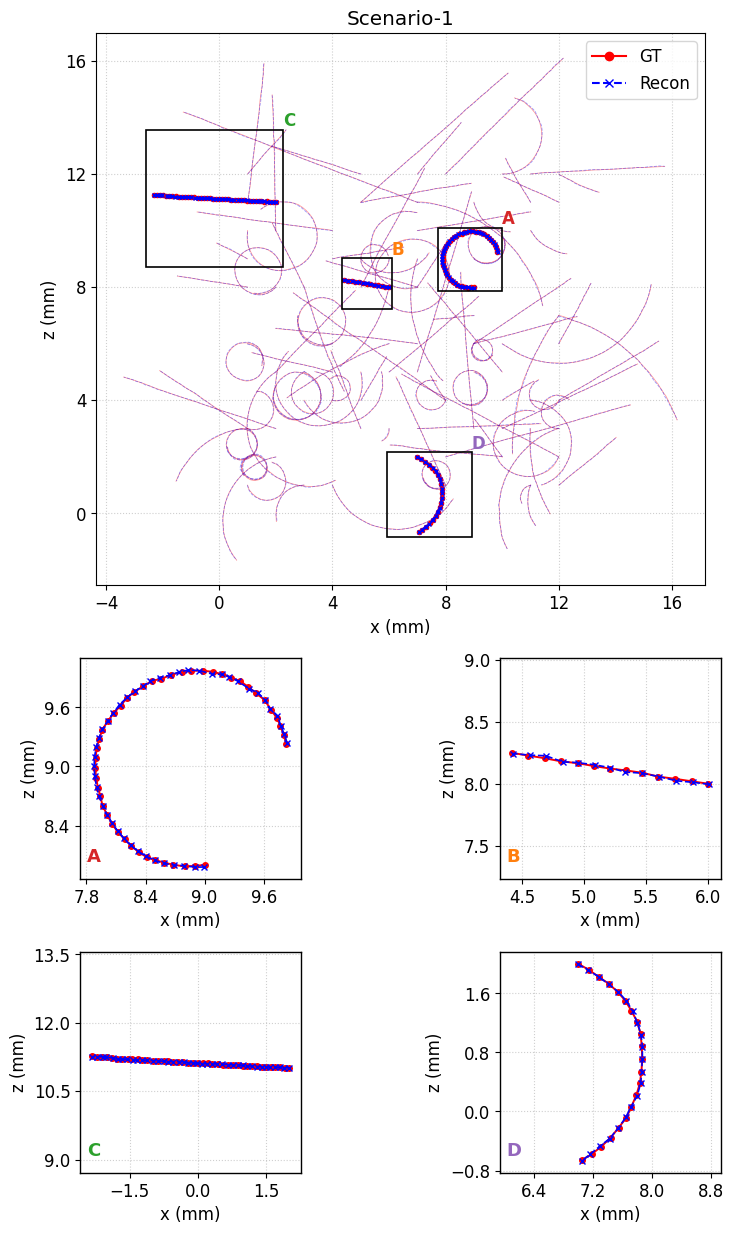

In [360]:
model= latentModule()
test= np.load('data/nonlinear/scenario_1/test.npy',allow_pickle=True).item()
scaler= joblib.load('standard_scaler_adaptive_global.pkl')
test_snippets= pre_process(test,delta_t,scaler,'test')
data_test= NODEDataset(test_snippets)
test_loader= DataLoader(dataset=data_test, batch_size=512, shuffle=True,collate_fn=custom_collate_func)
device = "cpu"
#model.load_state_dict(torch.load('TrajODE/model_seq2vec_3.pth'))
model.load_state_dict(torch.load('model_seq2vec_best.pth', map_location=torch.device('cpu')))
model.eval()

with torch.no_grad():
    feat, lengths = next(iter(test_loader))
    feat= feat.to(device)
    lengths= lengths.cpu()
    packed_input= pack_padded_sequence(feat,lengths,batch_first=True,enforce_sorted=False)
    pred = model(feat, packed_input)
    pred_decoded= pred.transpose(0,1)
    
    mu= torch.tensor(scaler.mean_[:2], device=feat.device, dtype=feat.dtype)
    sd=  torch.tensor(scaler.scale_[:2], device=feat.device, dtype=feat.dtype)

    feat[:,:,:2]= feat[:,:,:2]*sd+mu
    pred_decoded= pred_decoded*sd+mu

    #plot_reconstruction_with_insets(
    #      feat[:, :, :2],
    #      pred_decoded,
    #      lengths,title="Scenario - 1"
    #  )
    plot_reconstruction_with_grid_insets(
        feat[:, :, :2], pred_decoded, lengths, n=100, inset_indices=[0, 25, 42, 61],title="Scenario-1",grid_shape=(2,2))